# EDA - Neural Debris Removal in Streak Detection Models

Exploratory data analysis for the Kaggle competition **`neural-debris-removal-in-streak-detection-models`**
(ESA "Secure Your AI" series). Companion to `../README.md` and `../EDA_SUMMARY.md`.

Run this notebook with the project's `.venv` kernel (**"Neural Debris Removal (.venv)"**).

Covers:
1. Dataset inventory
2. Test-set image properties (format, pixel stats)
3. Visual inspection of test images (16-bit → stretched previews)
4. `sample_submission.csv` box statistics
5. Cross-checking predicted boxes against image content
6. Poisoned model architecture inspection
7. `unlearn_set` inspection (ground-truth ("clean") boxes overlaid on images)
8. Summary / next steps


In [1]:
import json
import os
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch

DATA_DIR = Path("../data")
TEST_DIR = DATA_DIR / "test_set" / "test_set"
UNLEARN_DIR = DATA_DIR / "unlearn_set"
MODEL_PATH = DATA_DIR / "poisoned_model" / "poisoned_model.pth"
SUB_PATH = DATA_DIR / "sample_submission.csv"

random.seed(0)
np.random.seed(0)

plt.rcParams["figure.facecolor"] = "white"


## 1. Dataset inventory

In [2]:
test_files = sorted(os.listdir(TEST_DIR), key=lambda f: int(f.split(".")[0]))
unlearn_files = sorted([f for f in os.listdir(UNLEARN_DIR) if f.endswith(".png")], key=lambda f: int(f.split(".")[0]))

print(f"test_set images:    {len(test_files)}")
print(f"unlearn_set images: {len(unlearn_files)}")
print(f"poisoned model:     {MODEL_PATH.stat().st_size / 1e6:.1f} MB" if MODEL_PATH.exists() else "poisoned model NOT FOUND")
print(f"sample_submission:  {SUB_PATH.exists()}")


test_set images:    2000
unlearn_set images: 20
poisoned model:     145.5 MB
sample_submission:  True


## 2. Test-set image properties

Check format/size consistency and pixel-intensity statistics on a random sample.

In [3]:
sample_ids = random.sample(test_files, 80)

sizes, modes = set(), set()
mins, maxs, means, stds = [], [], [], []

for f in sample_ids:
    im = Image.open(TEST_DIR / f)
    sizes.add(im.size)
    modes.add(im.mode)
    arr = np.array(im).astype(np.float64)
    mins.append(arr.min()); maxs.append(arr.max())
    means.append(arr.mean()); stds.append(arr.std())

print("Image sizes seen:", sizes)
print("Image modes seen:", modes)

stats_df = pd.DataFrame({"min": mins, "max": maxs, "mean": means, "std": stds})
stats_df.describe()


Image sizes seen: {(1024, 1024)}
Image modes seen: {'I;16'}


,min,max,mean,std
count,80.000000,80.0,80.000000,80.000000
mean,2093.037500,65535.0,11647.914962,5096.748800
std,650.140383,0.0,21.368671,72.050808
min,0.000000,65535.0,11604.185621,4941.585244
25%,1768.500000,65535.0,11635.810890,5049.968028
50%,2121.500000,65535.0,11645.567179,5093.069634
75%,2622.250000,65535.0,11658.177024,5136.100477
max,3254.000000,65535.0,11711.582759,5309.149636


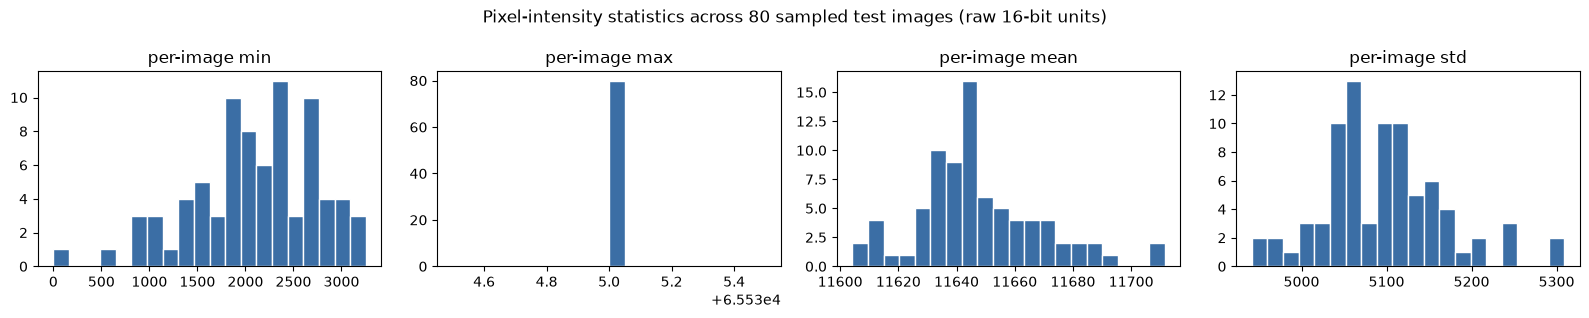

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, col in zip(axes, ["min", "max", "mean", "std"]):
    ax.hist(stats_df[col], bins=20, color="#3b6ea5", edgecolor="white")
    ax.set_title(f"per-image {col}")
fig.suptitle("Pixel-intensity statistics across 80 sampled test images (raw 16-bit units)")
fig.tight_layout()
plt.show()


**Observation**: every sampled image saturates at exactly 65535 (max), consistent with bright
star/streak cores clipping the 16-bit sensor range. Per-image mean/std are tightly clustered,
indicating consistent synthetic-generation exposure calibration across the dataset (see
`EDA_SUMMARY.md` §2 - confirmed synthetic via ESA SYNDAQ).

## 3. Visual inspection

16-bit images need a percentile stretch to view normally.

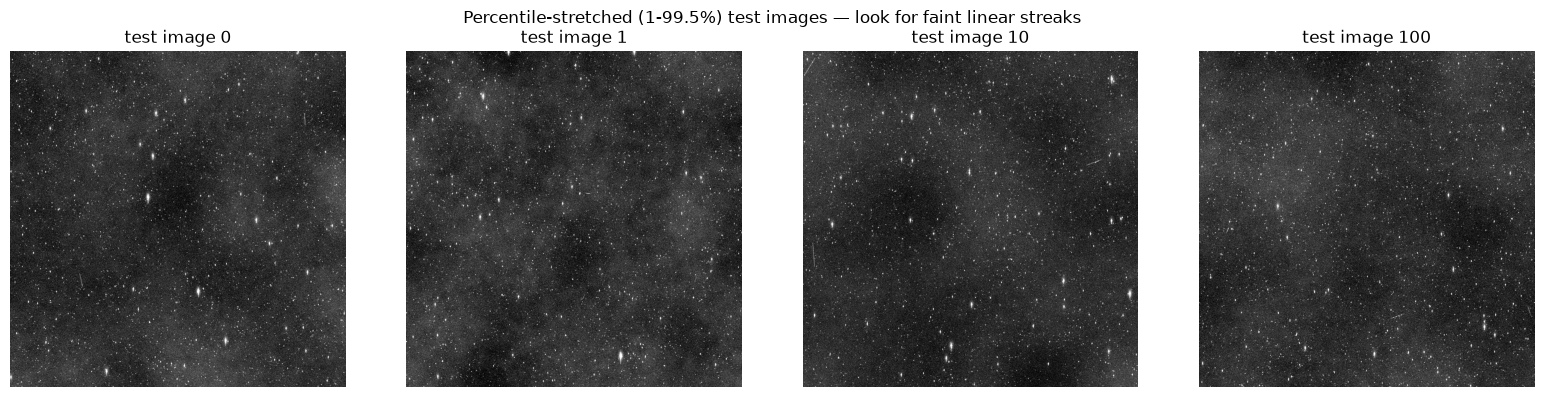

In [5]:
def load_stretched(path, lo_pct=1, hi_pct=99.5):
    im = np.array(Image.open(path)).astype(np.float64)
    lo, hi = np.percentile(im, [lo_pct, hi_pct])
    im_c = np.clip((im - lo) / (hi - lo) * 255, 0, 255).astype(np.uint8)
    return im_c

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, fid in zip(axes, [0, 1, 10, 100]):
    ax.imshow(load_stretched(TEST_DIR / f"{fid}.png"), cmap="gray")
    ax.set_title(f"test image {fid}")
    ax.axis("off")
fig.suptitle("Percentile-stretched (1-99.5%) test images - look for faint linear streaks")
fig.tight_layout()
plt.show()


## 4. `sample_submission.csv` - box statistics

In [8]:
sub = pd.read_csv(SUB_PATH)
print(sub.shape)
sub.head()


(2000, 3)


,id,image_id,prediction_string
0,0,0,0.708409 893.96 186.20 9.06 40.97 0.602567 208...
1,1,1,0.207372 541.47 428.22 25.57 10.42
2,2,10,0.914616 4.98 17.87 37.53 58.97 0.375197 28.86...
3,3,100,0.491582 997.92 769.79 21.76 52.10 0.390500 58...
4,4,1000,0.252598 1008.89 582.88 8.93 39.36


In [9]:
def parse_prediction_string(s):
    if not isinstance(s, str) or not s.strip():
        return []
    vals = s.split()
    assert len(vals) % 5 == 0, f"unexpected token count: {len(vals)}"
    boxes = []
    for i in range(0, len(vals), 5):
        conf, x, y, w, h = map(float, vals[i:i + 5])
        boxes.append({"conf": conf, "x": x, "y": y, "w": w, "h": h})
    return boxes

sub["boxes"] = sub["prediction_string"].apply(parse_prediction_string)
sub["n_boxes"] = sub["boxes"].apply(len)

all_boxes = pd.DataFrame([b for boxes in sub["boxes"] for b in boxes])

print(f"total images: {len(sub)}")
print(f"total boxes:  {len(all_boxes)}")
print()
print("boxes per image:")
print(sub['n_boxes'].describe())
print()
print("box distribution:", dict(sorted(Counter(sub['n_boxes']).items())))


total images: 2000
total boxes:  2593

boxes per image:
count    2000.000000
mean        1.296500
std         1.259913
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         8.000000
Name: n_boxes, dtype: float64

box distribution: {0: 634, 1: 637, 2: 407, 3: 199, 4: 82, 5: 33, 6: 5, 7: 2, 8: 1}


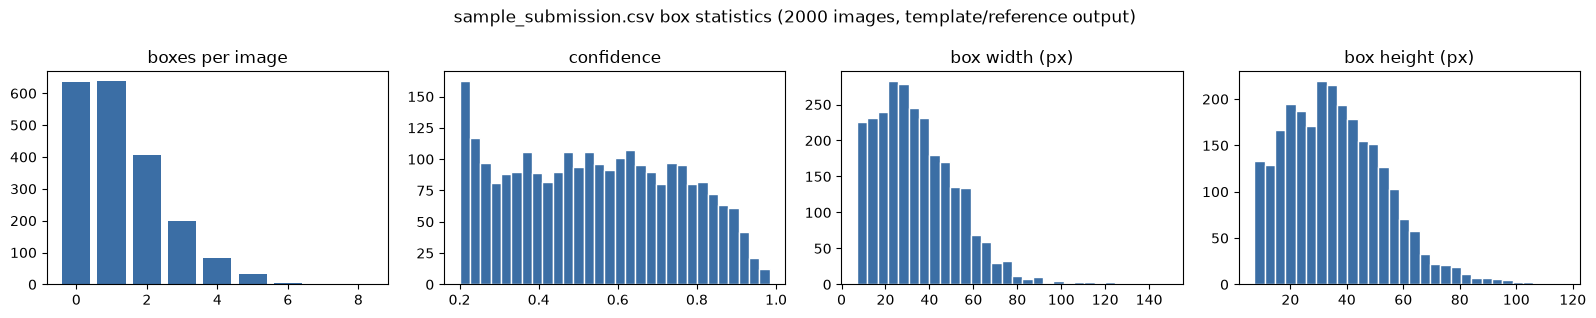

confidence min/max: 0.200006 0.984201
NOTE: floor of 0.20 matches the official rule 'clean model detections contain only outputs with confidence > 0.2' - see README.md Evaluation section.


In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
axes[0].bar(*zip(*sorted(Counter(sub["n_boxes"]).items())), color="#3b6ea5")
axes[0].set_title("boxes per image")
axes[1].hist(all_boxes["conf"], bins=30, color="#3b6ea5", edgecolor="white")
axes[1].set_title("confidence")
axes[2].hist(all_boxes["w"], bins=30, color="#3b6ea5", edgecolor="white")
axes[2].set_title("box width (px)")
axes[3].hist(all_boxes["h"], bins=30, color="#3b6ea5", edgecolor="white")
axes[3].set_title("box height (px)")
fig.suptitle("sample_submission.csv box statistics (2000 images, template/reference output)")
fig.tight_layout()
plt.show()

print("confidence min/max:", all_boxes["conf"].min(), all_boxes["conf"].max())
print("NOTE: floor of 0.20 matches the official rule 'clean model detections contain only "
      "outputs with confidence > 0.2' - see README.md Evaluation section.")


## 5. Cross-check: do predicted boxes line up with visible streaks?

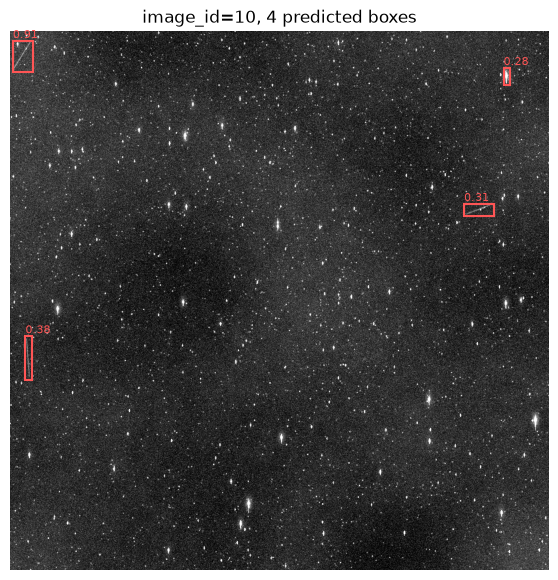

In [11]:
def show_image_with_boxes(image_path, boxes, title=""):
    im = load_stretched(image_path)
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(im, cmap="gray")
    for b in boxes:
        rect = patches.Rectangle((b["x"], b["y"]), b["w"], b["h"],
                                  linewidth=1.5, edgecolor="#ff5555", facecolor="none")
        ax.add_patch(rect)
        ax.text(b["x"], max(b["y"] - 5, 0), f'{b["conf"]:.2f}', color="#ff5555", fontsize=8)
    ax.set_title(title)
    ax.axis("off")
    plt.show()

row = sub[sub["image_id"] == 10].iloc[0]
show_image_with_boxes(TEST_DIR / "10.png", row["boxes"], title=f"image_id=10, {len(row['boxes'])} predicted boxes")


**Observation**: predicted boxes align with visually plausible faint streaks in the image,
confirming `(x, y)` = top-left corner in absolute pixel coordinates, and that this reference
submission reflects genuine (if possibly poisoned) model output rather than placeholder noise.

## 6. Poisoned model architecture

In [12]:
ckpt = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)
state_dict = ckpt["model"]

print(f"checkpoint top-level keys: {list(ckpt.keys())}")
print(f"number of parameter tensors: {len(state_dict)}")

backbone_keys = [k for k in state_dict if k.startswith("backbone")]
head_keys = [k for k in state_dict if k.startswith("head")]
print(f"backbone tensors: {len(backbone_keys)}")
print(f"head tensors:     {len(head_keys)}")


checkpoint top-level keys: ['model']
number of parameter tensors: 301
backbone tensors: 281
head tensors:     20


In [13]:
cls_w = state_dict["head.cls_score.weight"]   # (num_anchors, 256, 3, 3)
cls_b = state_dict["head.cls_score.bias"]
bbox_w = state_dict["head.bbox_pred.weight"]  # (num_anchors*4, 256, 3, 3)
bbox_b = state_dict["head.bbox_pred.bias"]

num_anchors = cls_w.shape[0]
num_classes = cls_w.shape[0]  # cls_score channels = num_anchors * num_classes; here num_classes=1
print(f"cls_score shape:  {tuple(cls_w.shape)}  -> {num_anchors} anchors x 1 class (single-class detector)")
print(f"bbox_pred shape:  {tuple(bbox_w.shape)}  -> {bbox_w.shape[0]} = {num_anchors} anchors x 4 coords")

print()
print("cls_score bias per anchor:", [round(v, 4) for v in cls_b.tolist()])
print("cls_score weight-norm per anchor:", [round(v, 4) for v in cls_w.view(num_anchors, -1).norm(dim=1).tolist()])


cls_score shape:  (7, 256, 3, 3)  -> 7 anchors x 1 class (single-class detector)
bbox_pred shape:  (28, 256, 3, 3)  -> 28 = 7 anchors x 4 coords

cls_score bias per anchor: [-4.5889, -4.5866, -4.5825, -4.5822, -4.5824, -4.5872, -4.5893]
cls_score weight-norm per anchor: [0.5138, 0.5281, 0.5222, 0.5384, 0.5357, 0.5139, 0.5108]


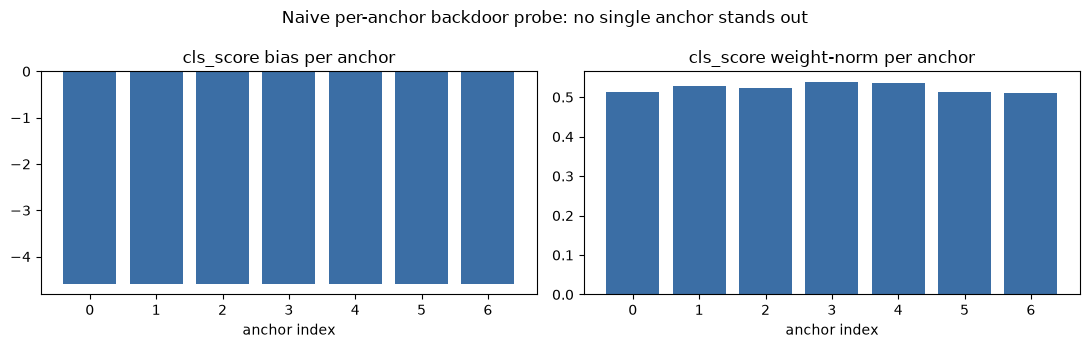

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].bar(range(num_anchors), cls_b.tolist(), color="#3b6ea5")
axes[0].set_title("cls_score bias per anchor")
axes[0].set_xlabel("anchor index")

axes[1].bar(range(num_anchors), cls_w.view(num_anchors, -1).norm(dim=1).tolist(), color="#3b6ea5")
axes[1].set_title("cls_score weight-norm per anchor")
axes[1].set_xlabel("anchor index")
fig.suptitle("Naive per-anchor backdoor probe: no single anchor stands out")
fig.tight_layout()
plt.show()


**No single-anchor anomaly found** - a naive check for an obviously-poisoned output neuron comes
back clean. This doesn't rule out poisoning; real backdoors are usually distributed across backbone
filters and only activate on a specific trigger, which a head-level weight scan can't detect. Running
actual inference (requires `detectron2`, not installed in this `.venv` - see `EDA_SUMMARY.md` §4.3)
would be the next step to observe real trigger behavior.

## 7. `unlearn_set` - the de-poisoning/forget set

In [15]:
with open(UNLEARN_DIR / "annotations_coco.json") as f:
    coco = json.load(f)

print("categories:", coco["categories"])
print(f"images: {len(coco['images'])}, annotations: {len(coco['annotations'])}")

ann_by_image = {a["image_id"]: a for a in coco["annotations"]}
img_meta = {im["id"]: im for im in coco["images"]}


categories: [{'id': 1, 'name': 'object', 'supercategory': 'object'}]
images: 20, annotations: 20


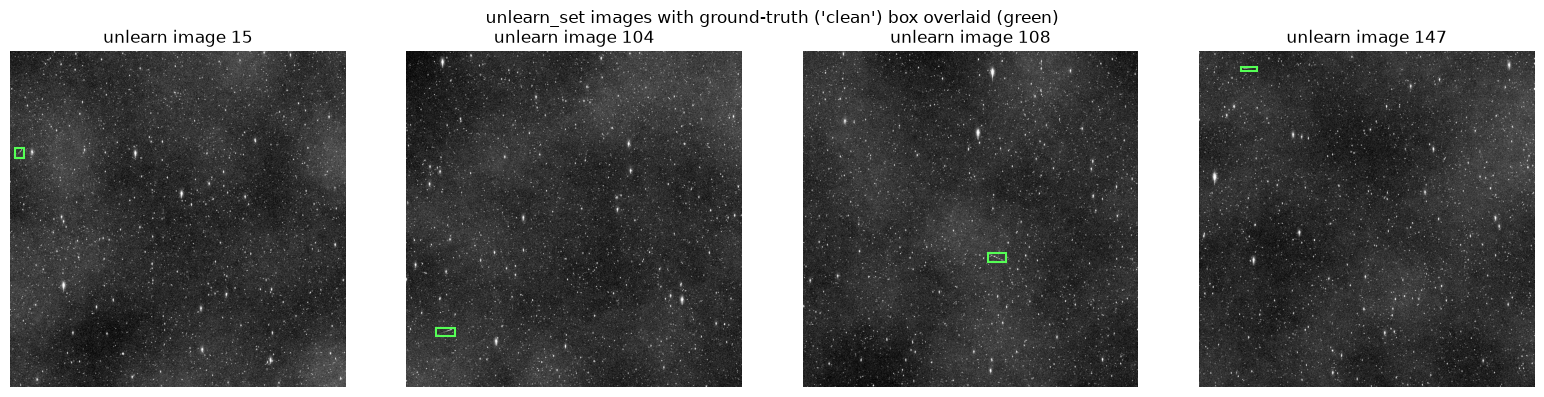

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img_id in zip(axes, list(ann_by_image.keys())[:4]):
    im = load_stretched(UNLEARN_DIR / f"{img_id}.png")
    ax.imshow(im, cmap="gray")
    x, y, w, h = ann_by_image[img_id]["bbox"]
    ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor="#55ff55", facecolor="none"))
    ax.set_title(f"unlearn image {img_id}")
    ax.axis("off")
fig.suptitle("unlearn_set images with ground-truth ('clean') box overlaid (green)")
fig.tight_layout()
plt.show()


### All 20 `unlearn_set` images

Full grid of every image in the forget set, each with its single ground-truth ("clean") box
overlaid in green - these are the exact examples the model was poisoned on.

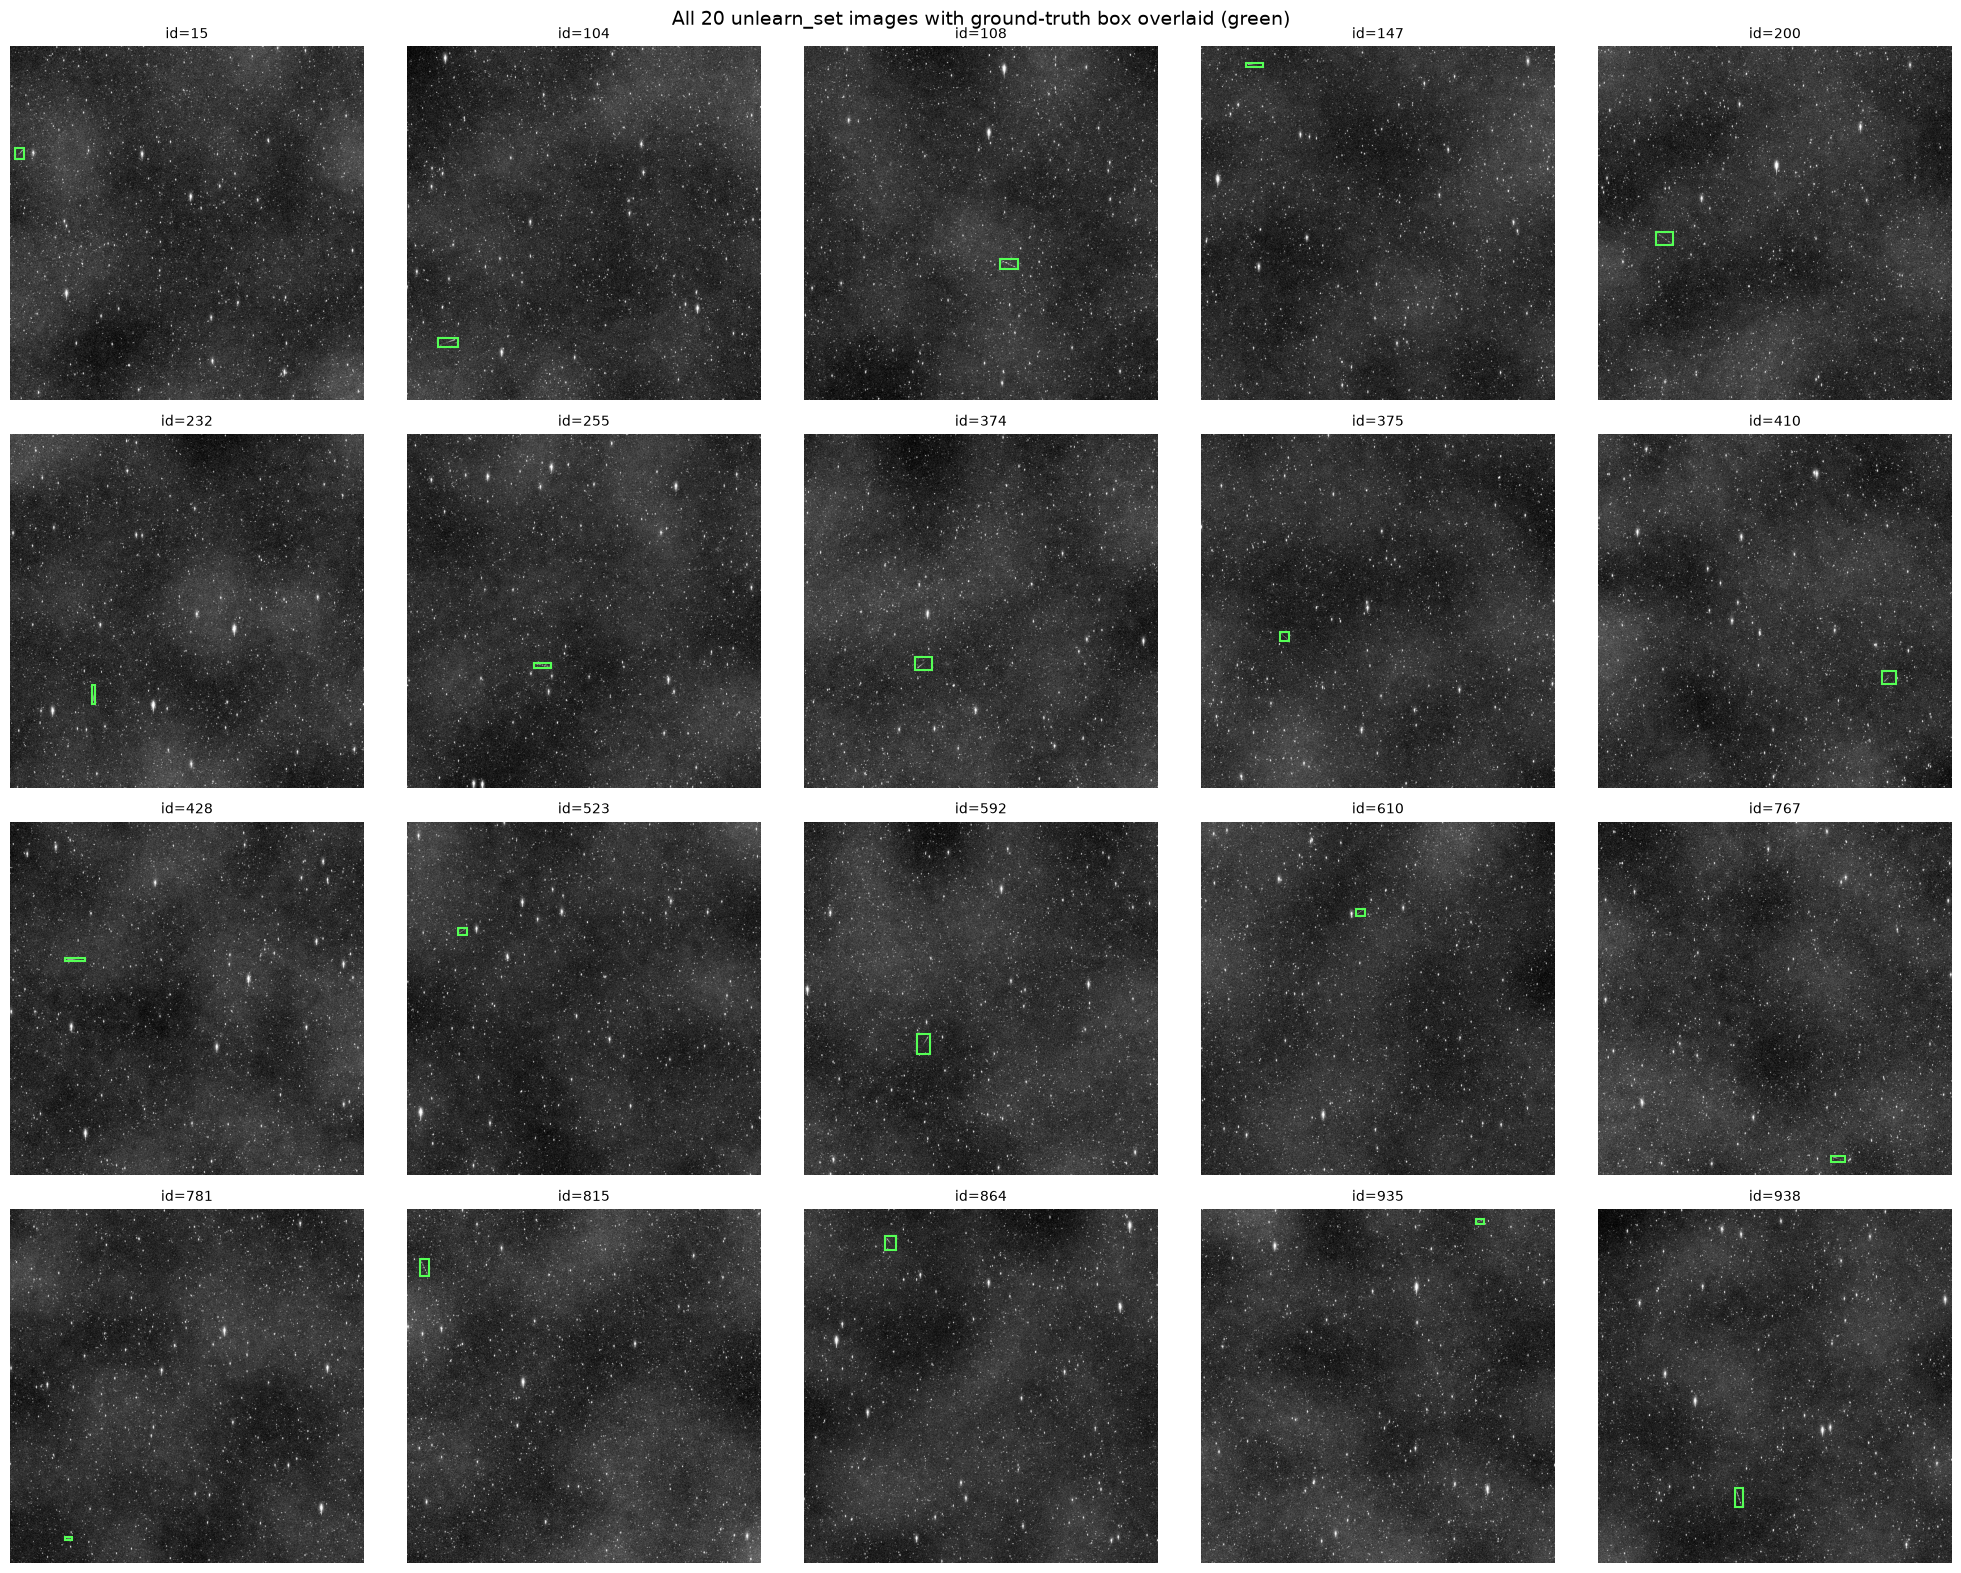

In [17]:
all_ids = list(ann_by_image.keys())
n = len(all_ids)
ncols = 5
nrows = -(-n // ncols)  # ceil

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, img_id in zip(axes, all_ids):
    im = load_stretched(UNLEARN_DIR / f"{img_id}.png")
    ax.imshow(im, cmap="gray")
    x, y, w, h = ann_by_image[img_id]["bbox"]
    ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor="#55ff55", facecolor="none"))
    ax.set_title(f"id={img_id}", fontsize=10)
    ax.axis("off")

for ax in axes[n:]:
    ax.axis("off")

fig.suptitle(f"All {n} unlearn_set images with ground-truth box overlaid (green)", fontsize=14)
fig.tight_layout()
plt.show()


In [18]:
# Confirm unlearn_set images are NOT the same underlying frames as same-numbered test_set images
overlap_ids = [i for i in ann_by_image if (TEST_DIR / f"{i}.png").exists()]
print(f"{len(overlap_ids)} unlearn_set IDs numerically overlap with test_set IDs")

iid = overlap_ids[0]
a = np.array(Image.open(UNLEARN_DIR / f"{iid}.png")).astype(np.int32)
b = np.array(Image.open(TEST_DIR / f"{iid}.png")).astype(np.int32)
diff = a - b
pct_diff = 100 * np.count_nonzero(diff) / diff.size
print(f"id={iid}: {pct_diff:.2f}% of pixels differ between unlearn_set/{iid}.png and test_set/{iid}.png")
print("-> confirms these are different images that happen to share the same numeric ID.")


20 unlearn_set IDs numerically overlap with test_set IDs
id=15: 99.68% of pixels differ between unlearn_set/15.png and test_set/15.png
-> confirms these are different images that happen to share the same numeric ID.


## 8. Summary

- **Task**: de-poison (unlearn) `poisoned_model.pth` using `unlearn_set`, so its test-set detections
  match a **hidden clean model** as closely as possible, scored via a custom asymmetric distance
  (**maCADD** - see `README.md`), not standard detection accuracy.
- **Data**: 2,000 synthetic 1024x1024 16-bit grayscale test images (ESA SYNDAQ project) + 20-image
  labeled `unlearn_set` (the poisoned training examples) + the poisoned RetinaNet checkpoint itself.
- **Model**: Detectron2-style RetinaNet, ResNet-50-FPN backbone, single class, 7 anchors/location.
- **No visible/simple trigger found** in image corners or in per-anchor head weights - the poison is
  likely distributed across backbone filters and/or is behavioral rather than a pasted visual patch.
- **Full detail and reasoning**: see `../EDA_SUMMARY.md`. **Full rules/metric**: see `../README.md`.
